# Recommandation client × catégorie × moment

Pipeline pas à pas : segmentation RFM, centres d’intérêt (catégories), puis modèle pour prioriser les clients à forte probabilité d’achat par catégorie (et saisonnalité).

**Étape 1** : imports et chargement de `data/sales_enriched.csv`.

Les chemins dans `category_name` sont séparés par ` / ` ; la **macro-catégorie** métier est l’**avant-dernier** segment (ex. INFORMATIQUE, GAMING, SON HIFI), stockée dans `category_macro`.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# ML / clustering (étapes suivantes)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)

# Répertoire du notebook → racine du projet
ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "sales_enriched.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["sale_date"])

# Macro-catégorie = avant-dernier niveau du chemin "A / B / C / D" → C
CATEGORY_PATH_SEP = " / "


def category_macro_from_path(name) -> str:
    if pd.isna(name) or not str(name).strip():
        return "UNKNOWN"
    parts = [p.strip() for p in str(name).split(CATEGORY_PATH_SEP) if p.strip()]
    if len(parts) < 2:
        return parts[0] if parts else "UNKNOWN"
    return parts[-2]


df["category_macro"] = df["category_name"].map(category_macro_from_path)

print(f"Fichier : {DATA_PATH.resolve()}")
print(f"Shape : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print("\nColonnes :", list(df.columns))
print(f"Macro-catégories distinctes : {df['category_macro'].nunique()}")
print("\nExemples category_name → category_macro :")
display(df[["category_name", "category_macro"]].drop_duplicates().head(12))
display(df.head())
display(df.dtypes)

/tmp/ipykernel_703018/91798998.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(DATA_PATH, parse_dates=["sale_date"])


Fichier : /home/raphael/Projects/jedha/segmentation/data/sales_enriched.csv
Shape : 63,875 lignes × 13 colonnes

Colonnes : ['partner_id', 'partner_name', 'order_state', 'order_id', 'product_id', 'product_name', 'category_id', 'category_name', 'sale_date', 'qty', 'price_unit', 'price_subtotal', 'category_macro']
Macro-catégories distinctes : 23

Exemples category_name → category_macro :


,category_name,category_macro
0,All / MARCHANDISES / INFORMATIQUE / Housse et ...,INFORMATIQUE
1,All / MARCHANDISES / GAMING / Manette,GAMING
2,All / MARCHANDISES / SON HIFI / Casques,SON HIFI
4,All / MARCHANDISES / GAMING / Gaming Jeux Vidéos,GAMING
6,All / MARCHANDISES / GAMING / Casques Gaming,GAMING
9,All / MARCHANDISES / GAMING / Accessoires Gaming,GAMING
10,All / MARCHANDISES / INFORMATIQUE / Ecrans,INFORMATIQUE
11,All / MARCHANDISES / INFORMATIQUE / Connectiqu...,INFORMATIQUE
12,All / MARCHANDISES / IMPRIMANTES / Imprimantes,IMPRIMANTES
13,All / MARCHANDISES / INFORMATIQUE / Onduleurs,INFORMATIQUE


,partner_id,partner_name,order_state,order_id,product_id,product_name,category_id,category_name,sale_date,qty,price_unit,price_subtotal,category_macro
0,7575,KINARA Luc,sale,36054,14781,"Case Logic Nylon 17"" Noir",89,All / MARCHANDISES / INFORMATIQUE / Housse et ...,2022-01-02,1.0,179000.0,179000.0,INFORMATIQUE
1,14377,LiXin,sale,36053,8500,Hori Zelda Noir Nintendo Switch,124,All / MARCHANDISES / GAMING / Manette,2022-01-02,1.0,257000.0,257000.0,GAMING
2,14377,LiXin,sale,36053,11767,JBL Tune 500 Bleu,64,All / MARCHANDISES / SON HIFI / Casques,2022-01-02,1.0,132000.0,132000.0,SON HIFI
3,19097,RAVOHANGIMALALA Isra,sale,36052,13031,V7 15.6'' Essential Backpack Noir,89,All / MARCHANDISES / INFORMATIQUE / Housse et ...,2022-01-02,1.0,88000.0,88000.0,INFORMATIQUE
4,13649,HERVE KING CHOW,sale,36051,10165,FIFA 22 PS4 VF,128,All / MARCHANDISES / GAMING / Gaming Jeux Vidéos,2022-01-02,1.0,369000.0,369000.0,GAMING


partner_id                 int64
partner_name                 str
order_state                  str
order_id                   int64
product_id                 int64
product_name                 str
category_id                int64
category_name                str
sale_date         datetime64[us]
qty                      float64
price_unit               float64
price_subtotal           float64
category_macro               str
dtype: object

## Calendrier, flags saisonniers (Madagascar)

Colonnes de calendrier sur `sale_date`, puis flags métier :

- **`is_xmax_period`** : pic **Noël / fin d’année** (novembre–décembre).
- **`is_holidays_out_of_xmax`** : autres fenêtres souvent sensibles au retail **hors** ce pic — **rentrée scolaire (~octobre)**, **semaine de l’Indépendance (24–28 juin)**, **début janvier** (1–10, post-fêtes).  
  Sous-drapeaux : `is_rentree_period`, `is_independence_period`, `is_newyear_start_period`.

Ensuite : échantillons, répartition du CA, courbes **CA mensuel** et **heatmap mois × macro** pour les **10 plus grosses macros** (en CA total).

In [3]:
d = df["sale_date"]

# --- Calendrier
df["cal_year"] = d.dt.year.astype("int16")
df["cal_month"] = d.dt.month.astype("int8")
df["cal_quarter"] = d.dt.quarter.astype("int8")
df["cal_day"] = d.dt.day.astype("int8")
df["cal_dow"] = d.dt.dayofweek.astype("int8")  # 0 = lundi
df["cal_is_weekend"] = (d.dt.dayofweek >= 5).astype("bool")

# --- Pic Noël / fin d'année
df["is_xmax_period"] = d.dt.month.isin([11, 12])

# --- Autres fenêtres (hors nov–déc)
df["is_rentree_period"] = d.dt.month.eq(10)
df["is_independence_period"] = d.dt.month.eq(6) & d.dt.day.between(24, 28)
df["is_newyear_start_period"] = d.dt.month.eq(1) & d.dt.day.between(1, 10)

df["is_holidays_out_of_xmax"] = (
    df["is_rentree_period"] | df["is_independence_period"] | df["is_newyear_start_period"]
)

cal_cols = [
    "cal_year",
    "cal_month",
    "cal_quarter",
    "cal_day",
    "cal_dow",
    "cal_is_weekend",
    "is_xmax_period",
    "is_holidays_out_of_xmax",
    "is_rentree_period",
    "is_independence_period",
    "is_newyear_start_period",
]
print("Colonnes calendrier / flags :", cal_cols)
print(f"Shape : {df.shape}")

Colonnes calendrier / flags : ['cal_year', 'cal_month', 'cal_quarter', 'cal_day', 'cal_dow', 'cal_is_weekend', 'is_xmax_period', 'is_holidays_out_of_xmax', 'is_rentree_period', 'is_independence_period', 'is_newyear_start_period']
Shape : (63875, 24)


## EDA — qualité des données, tops et graphiques

On résume la période couverte, l’état des commandes, puis les **tops** (**macro-catégories** `category_macro`, clients, produits) et quelques **vues temporelles** utiles pour la saisonnalité plus tard.

In [4]:
# Répartition du CA par zone (flags exclusifs : une ligne = une seule zone)
ca = df["price_subtotal"]
zone = np.where(
    df["is_xmax_period"],
    "xmax_nov_dec",
    np.where(df["is_holidays_out_of_xmax"], "autres_fetes_hors_xmax", "reste_annee"),
)
zone_ca = pd.DataFrame({"zone": zone, "price_subtotal": ca}).groupby("zone", as_index=False)[
    "price_subtotal"
].sum()
zone_ca["pct_CA"] = 100 * zone_ca["price_subtotal"] / zone_ca["price_subtotal"].sum()
zone_ca = zone_ca.sort_values("price_subtotal", ascending=False)

print("— CA par zone (mutuellement exclusif) —")
display(zone_ca)

# Top 10 macros (CA total) — utilisé pour courbes + heatmap
TOP_MACRO_N = 10
top_macros = (
    df.groupby("category_macro", as_index=False)["price_subtotal"]
    .sum()
    .sort_values("price_subtotal", ascending=False)
    .head(TOP_MACRO_N)["category_macro"]
    .tolist()
)
print(f"\nTop {TOP_MACRO_N} macros (CA total) :", top_macros)

# CA par macro dans xmax vs hors xmax (vue rapide)
sub_top = df[df["category_macro"].isin(top_macros)].copy()
sub_top["periode"] = np.where(sub_top["is_xmax_period"], "xmax", "hors_xmax")
pivot_x = (
    sub_top.groupby(["category_macro", "periode"], as_index=False)["price_subtotal"]
    .sum()
    .pivot(index="category_macro", columns="periode", values="price_subtotal")
    .fillna(0)
)
pivot_x["ratio_xmax_sur_hors"] = pivot_x.get("xmax", 0) / pivot_x.get("hors_xmax", 0).replace(0, np.nan)
pivot_x = pivot_x.reindex(top_macros)
print(f"\n— CA xmax vs hors xmax (top {TOP_MACRO_N} macros) —")
display(pivot_x)

— CA par zone (mutuellement exclusif) —


,zone,price_subtotal,pct_CA
1,reste_annee,3.196791e+10,63.865322
2,xmax_nov_dec,1.160061e+10,23.175642
0,autres_fetes_hors_xmax,6.486670e+09,12.959036



Top 10 macros (CA total) : ['INFORMATIQUE', 'LAPTOPS', 'GAMING', 'SON HIFI', 'IMPRIMANTES', 'TABLETTES', 'STOCKAGE', 'OBJETS CONNECTES', 'DESKTOPS', 'SMARTPHONES']

— CA xmax vs hors xmax (top 10 macros) —


periode,hors_xmax,xmax,ratio_xmax_sur_hors
category_macro,,,
INFORMATIQUE,1.683709e+10,4.300377e+09,0.255411
LAPTOPS,7.211500e+09,1.392308e+09,0.193068
GAMING,5.020508e+09,2.686811e+09,0.535167
SON HIFI,4.546426e+09,1.962431e+09,0.431643
IMPRIMANTES,2.022623e+09,3.188225e+08,0.157628
TABLETTES,7.752659e+08,5.015604e+08,0.646953
STOCKAGE,4.712368e+08,1.061302e+08,0.225216
OBJETS CONNECTES,4.436964e+08,1.130972e+08,0.254898
DESKTOPS,4.976997e+08,3.843898e+07,0.077233


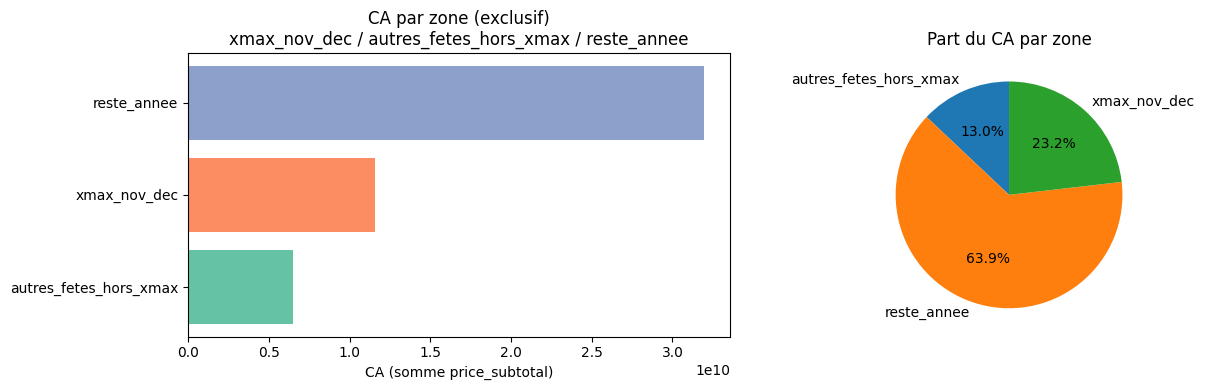

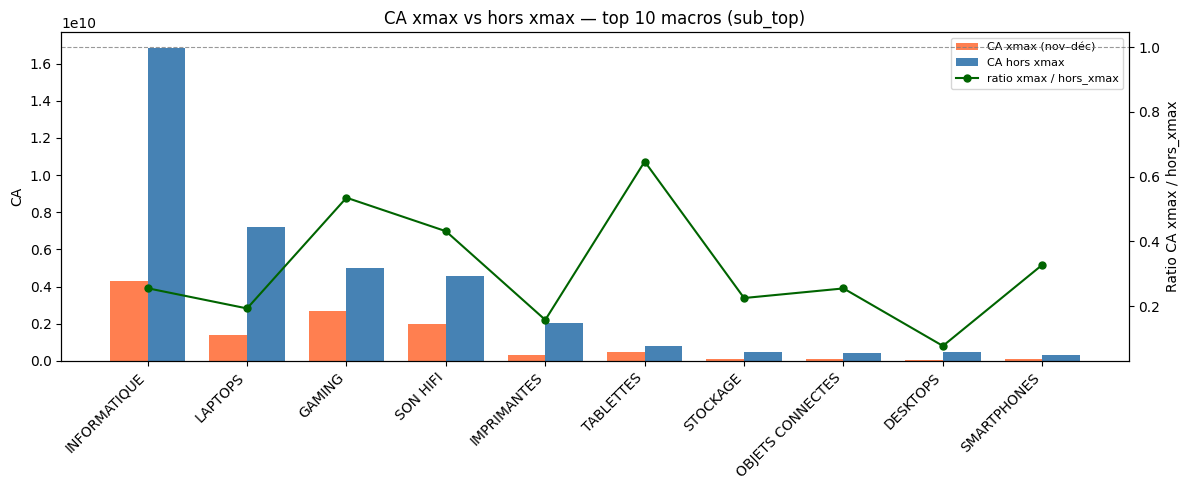

In [5]:
# Graphiques : CA par zone (exclusif) + xmax vs hors_xmax (top macros) + ratio

# --- 1) Trois zones mutuellement exclusives
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

zplot = zone_ca.sort_values("price_subtotal", ascending=True)
axes[0].barh(
    zplot["zone"],
    zplot["price_subtotal"],
    color=sns.color_palette("Set2", n_colors=len(zplot)),
)
axes[0].set_title(
    "CA par zone (exclusif)\nxmax_nov_dec / autres_fetes_hors_xmax / reste_annee"
)
axes[0].set_xlabel("CA (somme price_subtotal)")

axes[1].pie(
    zone_ca.sort_values("zone")["price_subtotal"],
    labels=zone_ca.sort_values("zone")["zone"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Part du CA par zone")

plt.tight_layout()
plt.show()

# --- 2) Top macros : barres groupées (xmax vs hors_xmax) + ratio sur axe secondaire
px = pivot_x.copy()
if "xmax" not in px.columns:
    px["xmax"] = 0.0
if "hors_xmax" not in px.columns:
    px["hors_xmax"] = 0.0

px_plot = px.reset_index()  # index → colonne category_macro (pivot sub_top)

x = np.arange(len(px_plot))
w = 0.38
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(x - w / 2, px_plot["xmax"], width=w, label="CA xmax (nov–déc)", color="coral")
ax1.bar(x + w / 2, px_plot["hors_xmax"], width=w, label="CA hors xmax", color="steelblue")
ax1.set_xticks(x)
ax1.set_xticklabels(px_plot["category_macro"], rotation=45, ha="right")
ax1.set_ylabel("CA")
ax1.set_title(f"CA xmax vs hors xmax — top {TOP_MACRO_N} macros (sub_top)")

ax2 = ax1.twinx()
ax2.plot(
    x,
    px_plot["ratio_xmax_sur_hors"],
    color="darkgreen",
    marker="o",
    linewidth=1.5,
    markersize=5,
    label="ratio xmax / hors_xmax",
)
ax2.set_ylabel("Ratio CA xmax / hors_xmax")
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.8)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

In [6]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12

TOP_N = 15

print("— Valeurs manquantes par colonne —")
display(df.isna().sum().to_frame("manquants"))

dup_all = df.duplicated().sum()
print(f"Lignes entièrement dupliquées : {dup_all:,}")

print("\n— Période & volumétrie —")
print(f"Dates : {df['sale_date'].min().date()} → {df['sale_date'].max().date()}")
print(f"Lignes de vente : {len(df):,}")
print(f"Clients uniques (partner_id) : {df['partner_id'].nunique():,}")
print(f"Commandes uniques (order_id) : {df['order_id'].nunique():,}")
print(f"Produits uniques : {df['product_id'].nunique():,}")
print(f"Catégories uniques : {df['category_id'].nunique():,}")

print("\n— États de commande (order_state) —")
display(df["order_state"].value_counts().to_frame("lignes"))

— Valeurs manquantes par colonne —


,manquants
partner_id,0
partner_name,0
order_state,0
order_id,0
product_id,0
product_name,0
category_id,0
category_name,0
sale_date,0
qty,0


Lignes entièrement dupliquées : 51

— Période & volumétrie —
Dates : 2022-01-02 → 2026-03-11
Lignes de vente : 63,875
Clients uniques (partner_id) : 26,745
Commandes uniques (order_id) : 48,278
Produits uniques : 3,132
Catégories uniques : 65

— États de commande (order_state) —


,lignes
order_state,
sale,63866
done,9


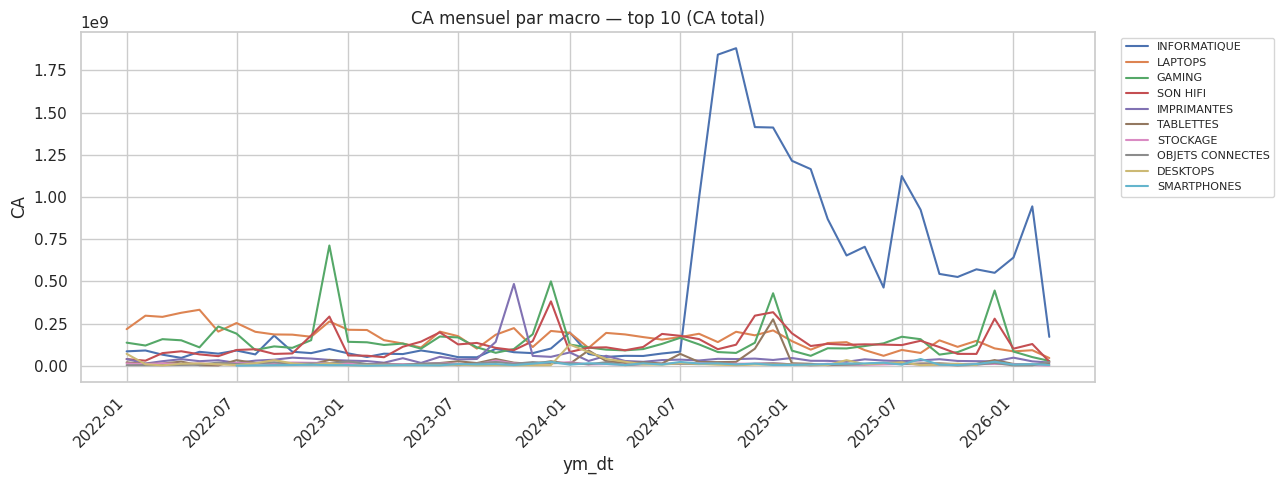

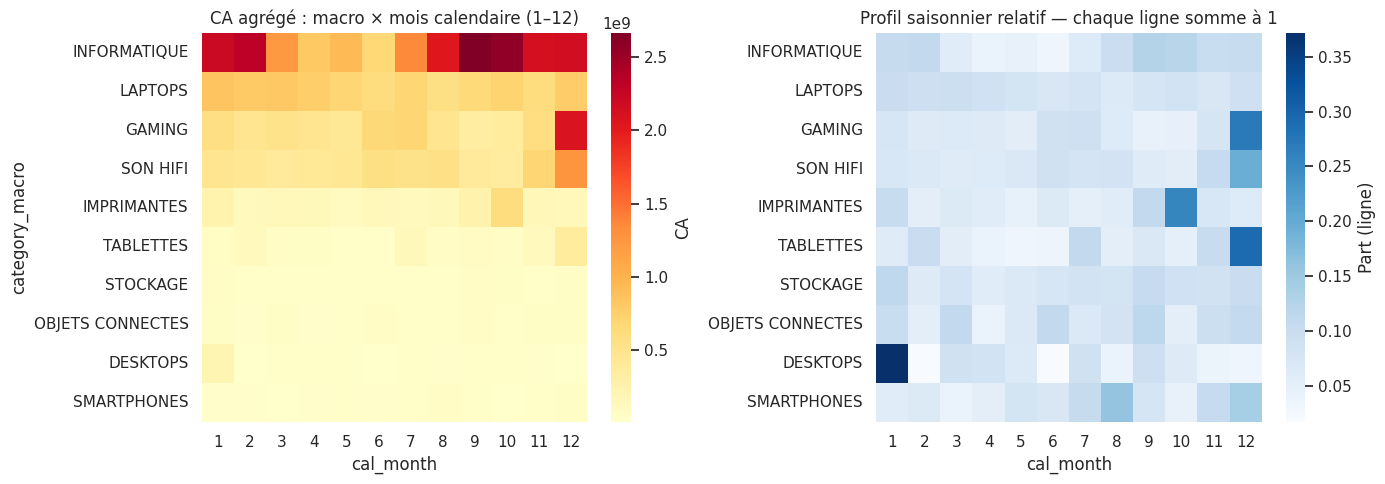

In [7]:
# Top 10 macros : CA mensuel (série temporelle) + heatmap mois × macro
df_tm = df[df["category_macro"].isin(top_macros)].copy()
df_tm["ym"] = df_tm["sale_date"].dt.to_period("M")
curve = df_tm.groupby(["category_macro", "ym"], as_index=False)["price_subtotal"].sum()
curve["ym_dt"] = curve["ym"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(
    data=curve,
    x="ym_dt",
    y="price_subtotal",
    hue="category_macro",
    hue_order=top_macros,
    ax=ax,
)
ax.set_title(f"CA mensuel par macro — top {TOP_MACRO_N} (CA total)")
ax.set_ylabel("CA")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

h = (
    df_tm.groupby(["category_macro", "cal_month"], as_index=False)["price_subtotal"]
    .sum()
    .pivot(index="category_macro", columns="cal_month", values="price_subtotal")
    .fillna(0)
)
h = h.reindex(top_macros).reindex(columns=range(1, 13), fill_value=0)
h_norm = h.div(h.sum(axis=1).replace(0, np.nan), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(h, ax=axes[0], cmap="YlOrRd", cbar_kws={"label": "CA"})
axes[0].set_title("CA agrégé : macro × mois calendaire (1–12)")
axes[0].set_xlabel("cal_month")
axes[0].set_ylabel("category_macro")

sns.heatmap(h_norm, ax=axes[1], cmap="Blues", cbar_kws={"label": "Part (ligne)"})
axes[1].set_title("Profil saisonnier relatif — chaque ligne somme à 1")
axes[1].set_xlabel("cal_month")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [8]:
# Tops : CA = somme de price_subtotal (agrégation par macro-catégorie)

top_cat_ca = (
    df.groupby("category_macro", as_index=False)["price_subtotal"]
    .sum()
    .sort_values("price_subtotal", ascending=False)
    .head(TOP_N)
    .rename(columns={"category_macro": "Macro_catégorie", "price_subtotal": "CA"})
)

top_cat_lines = (
    df["category_macro"]
    .value_counts()
    .head(TOP_N)
    .rename_axis("Macro_catégorie")
    .reset_index(name="Nb_lignes")
)

top_clients_ca = (
    df.groupby(["partner_id", "partner_name"], as_index=False)["price_subtotal"]
    .sum()
    .sort_values("price_subtotal", ascending=False)
    .head(TOP_N)
    .rename(columns={"price_subtotal": "CA"})
)

top_products_ca = (
    df.groupby(["product_id", "product_name"], as_index=False)["price_subtotal"]
    .sum()
    .sort_values("price_subtotal", ascending=False)
    .head(TOP_N)
    .rename(columns={"price_subtotal": "CA"})
)

print(f"Top {TOP_N} catégories par CA")
display(top_cat_ca)
print(f"Top {TOP_N} catégories par nombre de lignes")
display(top_cat_lines)
print(f"Top {TOP_N} clients par CA")
display(top_clients_ca)
print(f"Top {TOP_N} produits par CA")
display(top_products_ca)

Top 15 catégories par CA


,Macro_catégorie,CA
9,INFORMATIQUE,2.113746e+10
11,LAPTOPS,8.603808e+09
6,GAMING,7.707319e+09
18,SON HIFI,6.508857e+09
8,IMPRIMANTES,2.341446e+09
22,TABLETTES,1.276826e+09
20,STOCKAGE,5.773670e+08
14,OBJETS CONNECTES,5.567936e+08
5,DESKTOPS,5.361387e+08
17,SMARTPHONES,3.885313e+08


Top 15 catégories par nombre de lignes


,Macro_catégorie,Nb_lignes
0,INFORMATIQUE,23126
1,GAMING,18415
2,SON HIFI,9146
3,IMPRIMANTES,3525
4,STOCKAGE,2682
5,LAPTOPS,2658
6,TABLETTE ET TELEPHONIE,1555
7,OBJETS CONNECTES,1017
8,TABLETTES,925
9,SMARTPHONES,410


Top 15 clients par CA


,partner_id,partner_name,CA
3029,14819,MASS'IN TAMATAVE - SOCIETE JAFRI HI-TECH,2.784634e+09
39,638,NEXTHOPE,1.984890e+09
4654,20937,"Agence Portuaire, Maritime et Fluvial (APMF)",9.400290e+08
13669,33550,EXTRATOO,3.837439e+08
1464,7836,MAMY GOTSO,3.425435e+08
14205,34420,INTC,2.686989e+08
17053,39023,RALAIBOZAKA Harijaona Gabriel,2.159010e+08
7902,25537,PEREGRINE,1.829060e+08
2741,13442,HAIRUN TECHNOLOGY,1.696222e+08
1047,5490,Rouge Hexagone,1.463788e+08


Top 15 produits par CA


,product_id,product_name,CA
117,8054,StarlinK Standard Kit V4,8.890958e+09
118,8055,StarlinK Mini Kit,4.959166e+09
116,8053,Starlink Standard Actuated Kit,2.327833e+09
2451,13627,JBL PartyBox 310 Noir,9.616968e+08
2697,14712,Onduleur UPS Technology InLine 850VA,9.356119e+08
2459,13635,JBL PARTYBOX STAGE 320,5.838529e+08
2450,13626,JBL PartyBox 110 Noir,3.496623e+08
246,8288,Console Sony PS5 Edition Standard Chassis B,3.091886e+08
1674,11985,"Logitech G29 Driving Force pour PS3, PS4, PS5 ...",3.011556e+08
2260,12989,Epson EcoTank L3250,2.674526e+08


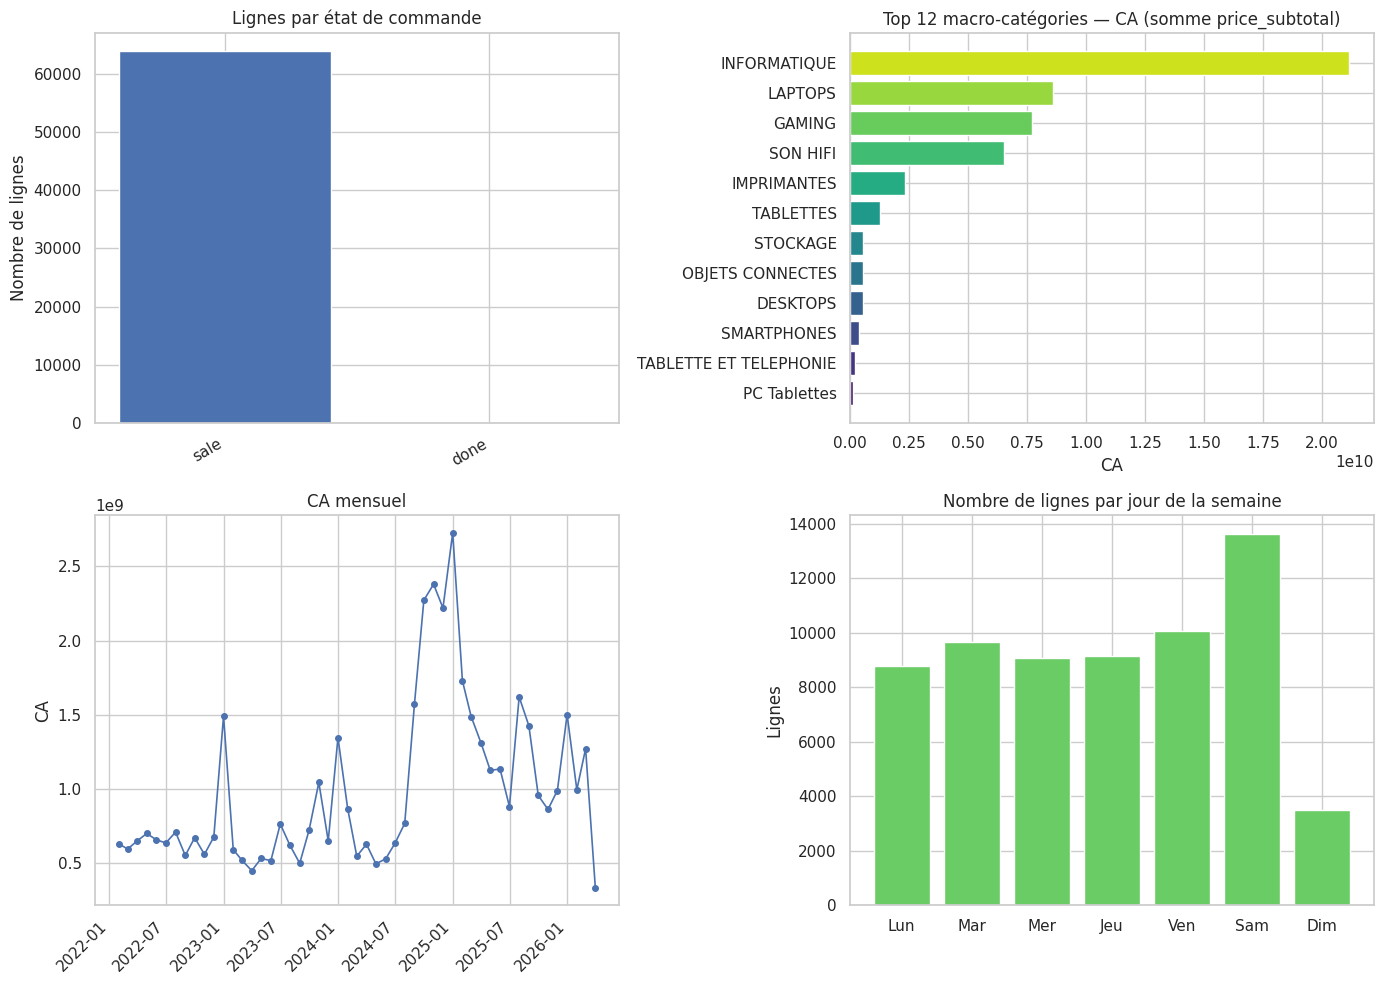

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 — États de commande
ax = axes[0, 0]
vc = df["order_state"].value_counts()
ax.bar(vc.index.astype(str), vc.values, color=sns.color_palette("deep")[0])
ax.set_title("Lignes par état de commande")
ax.set_ylabel("Nombre de lignes")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

# 2 — Top macro-catégories (CA)
ax = axes[0, 1]
d = top_cat_ca.head(12).iloc[::-1].copy()
d["label"] = d["Macro_catégorie"].astype(str).str.slice(0, 55)
ax.barh(d["label"], d["CA"], color=sns.color_palette("viridis", n_colors=len(d)))
ax.set_title("Top 12 macro-catégories — CA (somme price_subtotal)")
ax.set_xlabel("CA")

# 3 — CA agrégé par mois
ax = axes[1, 0]
# pandas 2.2+ : "ME" (fin de mois) ; ici pandas 2.1.x : "M"
monthly = df.set_index("sale_date").resample("ME")["price_subtotal"].sum()
ax.plot(monthly.index, monthly.values, marker="o", markersize=4, linewidth=1.2)
ax.set_title("CA mensuel")
ax.set_ylabel("CA")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# 4 — Volume par jour de la semaine
ax = axes[1, 1]
labels = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
dow_counts = df["sale_date"].dt.dayofweek.value_counts().reindex(range(7), fill_value=0)
ax.bar(labels, dow_counts.values, color=sns.color_palette("muted")[2])
ax.set_title("Nombre de lignes par jour de la semaine")
ax.set_ylabel("Lignes")

plt.tight_layout()
plt.show()

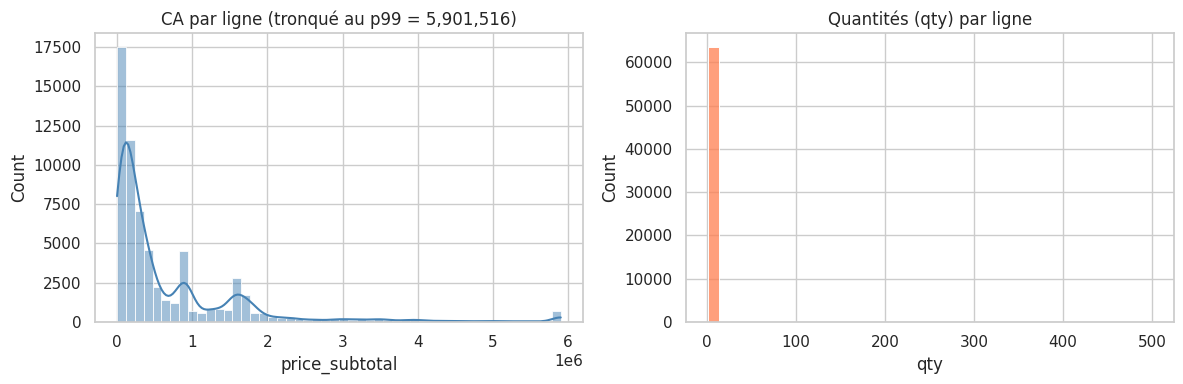

In [10]:
# Distributions (lignes de vente) — CA tronqué au 99e percentile pour lisibilité
ca_cap = df["price_subtotal"].quantile(0.99)
ca_plot = df["price_subtotal"].clip(upper=ca_cap)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(ca_plot, bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title(f"CA par ligne (tronqué au p99 = {ca_cap:,.0f})")
axes[0].set_xlabel("price_subtotal")

sns.histplot(df["qty"].dropna(), bins=40, kde=False, ax=axes[1], color="coral")
axes[1].set_title("Quantités (qty) par ligne")
axes[1].set_xlabel("qty")

plt.tight_layout()
plt.show()

## Segmentation RFM

Les cellules suivantes décrivent les segments (**Q / R**), calculent **R, F, M**, les scores quintiles et les segments **Champions / Fidèles / À risque / Dormants**, ajoutent les tags **B2B**, **Noël** (`Tag_Christmas_Shopper`, `Pct_Christmas`), **autres fenêtres calendaires** hors pic Noël (`Tag_Holidays_Shopper`, `Pct_Holidays`, voir section calendrier), **centre d’intérêt** (`interest_tag` = macro-catégorie dominante en CA), exportent le tout dans **`data/rfm_segments.csv`**, puis affichent les graphiques.

### Détail méthodologique (fenêtre temporelle, `sale` uniquement)

- **Données** : lignes avec `order_state == "sale"` uniquement.  
- **Date de référence** : jour du **dernier achat** dans cette base filtrée.  
- **Fenêtre** : réglée par **`RFM_WINDOW_MONTHS`** dans la cellule RFM — `None` = **tout l’historique** (`min(sale_date)` → ref.) ; un entier (ex. `12`) = **N derniers mois** glissants avant la référence.  
- **R** : nombre de jours entre la date de référence et le **dernier** achat du client dans la fenêtre (plus c’est bas, plus c’est récent).  
- **F** : nombre de **commandes** distinctes (`order_id`) dans la fenêtre.  
- **M** : somme des `price_subtotal` dans la fenêtre.  
- **Scores 1–5** : quintiles sur la base active (R inversé : score 5 = plus récent).  
- **Segments** (règles sur scores) : **Champions**, **Fidèles**, **À risque**, **Dormants**.

In [11]:
# Segmentation RFM : calcule rfm, df_rfm_win (nécessite df, category_macro ou category_macro_from_path — cellule chargement)
from IPython.display import display

# --- Base ventes "sale" + fenêtre (historique complet ou N mois)
df_sales = df.loc[df["order_state"].eq("sale")].copy()
REFERENCE_DATE = df_sales["sale_date"].max().normalize()

# None = tout l'historique disponible ; 12 = 12 derniers mois glissants, etc.
RFM_WINDOW_MONTHS = None

if RFM_WINDOW_MONTHS is None:
    WINDOW_START = df_sales["sale_date"].min().normalize()
    _win_desc = "historique complet (sale)"
else:
    WINDOW_START = REFERENCE_DATE - pd.DateOffset(months=int(RFM_WINDOW_MONTHS))
    _win_desc = f"{RFM_WINDOW_MONTHS} derniers mois (sale)"

df_rfm_win = df_sales.loc[
    (df_sales["sale_date"] >= WINDOW_START) & (df_sales["sale_date"] <= REFERENCE_DATE)
].copy()

print(f"Date de référence : {REFERENCE_DATE.date()}")
print(f"Fenêtre : {WINDOW_START.date()} → {REFERENCE_DATE.date()} — {_win_desc}")
print(f"Lignes dans la fenêtre : {len(df_rfm_win):,} | Clients distincts : {df_rfm_win['partner_id'].nunique():,}")

# --- Agrégation RFM par client
rfm = (
    df_rfm_win.groupby("partner_id", as_index=False)
    .agg(
        last_purchase=("sale_date", "max"),
        frequency=("order_id", "nunique"),
        monetary=("price_subtotal", "sum"),
    )
)
rfm["recency_days"] = (REFERENCE_DATE - rfm["last_purchase"]).dt.days.astype("int64")

# Nom client (mode, sinon première occurrence)
_partner_name = df_rfm_win.sort_values("sale_date").groupby("partner_id")["partner_name"].agg(
    lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]
)
rfm = rfm.merge(_partner_name.rename("partner_name"), on="partner_id", how="left")

# --- Quintiles → scores 1–5 (R inversé : 5 = plus récent)
_rank = {"method": "first"}


def q5_scores_asc(series: pd.Series, *, low_is_bad: bool) -> pd.Series:
    """low_is_bad=True → petites valeurs = score 1 (ex. F, M). low_is_bad=False → petites valeurs = score 5 (ex. R jours)."""
    r = series.rank(**_rank)
    if low_is_bad:
        return pd.qcut(r, q=5, labels=[1, 2, 3, 4, 5], duplicates="drop").astype("int8")
    return pd.qcut(r, q=5, labels=[5, 4, 3, 2, 1], duplicates="drop").astype("int8")


rfm["R_score"] = q5_scores_asc(rfm["recency_days"], low_is_bad=False)
rfm["F_score"] = q5_scores_asc(rfm["frequency"], low_is_bad=True)
rfm["M_score"] = q5_scores_asc(rfm["monetary"], low_is_bad=True)


def rfm_segment(row: pd.Series) -> str:
    r, f, m = int(row["R_score"]), int(row["F_score"]), int(row["M_score"])
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    if r <= 2 and f <= 2 and m <= 2:
        return "Dormants"
    if r <= 2 and (f >= 3 or m >= 3):
        return "À risque"
    if r >= 3 and f >= 3 and m >= 3:
        return "Fidèles"
    if r >= 4 or (f >= 3 and m >= 3):
        return "Fidèles"
    if r <= 2:
        return "À risque"
    return "Fidèles"


rfm["segment"] = rfm.apply(rfm_segment, axis=1)

# --- Tags comportementaux (toutes les ventes « sale », comme prophecy_seg ; Noël / fêtes = flags calendrier si présents)
_s = df_sales["sale_date"]
_is_xmax = (
    df_sales["is_xmax_period"]
    if "is_xmax_period" in df_sales.columns
    else _s.dt.month.isin([11, 12])
)
_is_holidays_ox = (
    df_sales["is_holidays_out_of_xmax"]
    if "is_holidays_out_of_xmax" in df_sales.columns
    else (
        _s.dt.month.eq(10)
        | (_s.dt.month.eq(6) & _s.dt.day.between(24, 28))
        | (_s.dt.month.eq(1) & _s.dt.day.between(1, 10))
    )
)

b2b_keywords = "RESEAU|Onduleurs|Toner|Desktops|Serveur|FOURNITURES|STRUCTURE"
_is_b2b = df_sales["category_name"].str.contains(b2b_keywords, case=False, na=False)
b2b_profile = (
    df_sales.assign(is_b2b_category=_is_b2b)
    .groupby("partner_id")
    .agg(
        Max_Qty_Single_Item=("qty", "max"),
        Count_B2B_Items=("is_b2b_category", "sum"),
    )
    .reset_index()
)
b2b_profile["Tag_B2B"] = (b2b_profile["Max_Qty_Single_Item"] >= 5) | (b2b_profile["Count_B2B_Items"] >= 2)
b2b_tags = b2b_profile[["partner_id", "Tag_B2B"]]

seasonality = (
    df_sales.assign(is_xmax_purchase=_is_xmax)
    .groupby("partner_id")
    .agg(
        total_purchases=("order_id", "count"),
        christmas_purchases=("is_xmax_purchase", "sum"),
    )
    .reset_index()
)
seasonality["Pct_Christmas"] = seasonality["christmas_purchases"] / seasonality["total_purchases"]
seasonality["Tag_Christmas_Shopper"] = seasonality["Pct_Christmas"] >= 0.50
seasonality_tags = seasonality[["partner_id", "Tag_Christmas_Shopper", "Pct_Christmas"]]

holidays_agg = (
    df_sales.assign(is_holidays_purchase=_is_holidays_ox)
    .groupby("partner_id")
    .agg(
        _h_total=("order_id", "count"),
        _h_cnt=("is_holidays_purchase", "sum"),
    )
    .reset_index()
)
holidays_agg["Pct_Holidays"] = holidays_agg["_h_cnt"] / holidays_agg["_h_total"]
holidays_agg["Tag_Holidays_Shopper"] = holidays_agg["Pct_Holidays"] >= 0.50
holidays_tags = holidays_agg[["partner_id", "Tag_Holidays_Shopper", "Pct_Holidays"]]

if "category_macro" in df_sales.columns:
    _macro_series = df_sales["category_macro"].fillna("INCONNU").astype(str)
else:
    _macro_series = df_sales["category_name"].map(category_macro_from_path).fillna("INCONNU").astype(str)
_spend = df_sales.assign(_macro=_macro_series).groupby(["partner_id", "_macro"], as_index=False)["price_subtotal"].sum()
top_cat = _spend.sort_values(["partner_id", "price_subtotal"], ascending=[True, False]).drop_duplicates(
    subset=["partner_id"]
)
interest_tags = top_cat.rename(columns={"_macro": "Tag_Interest"})[["partner_id", "Tag_Interest"]]

rfm = rfm.merge(seasonality_tags, on="partner_id", how="left")
rfm = rfm.merge(holidays_tags, on="partner_id", how="left")
rfm = rfm.merge(b2b_tags, on="partner_id", how="left")
rfm = rfm.merge(interest_tags, on="partner_id", how="left")
rfm["Tag_Christmas_Shopper"] = rfm["Tag_Christmas_Shopper"].fillna(False)
rfm["Pct_Christmas"] = rfm["Pct_Christmas"].fillna(0.0)
rfm["Tag_Holidays_Shopper"] = rfm["Tag_Holidays_Shopper"].fillna(False)
rfm["Pct_Holidays"] = rfm["Pct_Holidays"].fillna(0.0)
rfm["Tag_B2B"] = rfm["Tag_B2B"].fillna(False)
rfm["Tag_Interest"] = rfm["Tag_Interest"].fillna("INCONNU")

print("\nEffectifs par segment :")
display(rfm["segment"].value_counts().rename_axis("segment").reset_index(name="clients"))

print("\nÉchantillon :")
display(
    rfm.sort_values(["segment", "monetary"], ascending=[True, False]).head(15)[
        [
            "partner_id",
            "partner_name",
            "recency_days",
            "frequency",
            "monetary",
            "R_score",
            "F_score",
            "M_score",
            "segment",
            "Tag_B2B",
            "Tag_Christmas_Shopper",
            "Tag_Holidays_Shopper",
            "Tag_Interest",
        ]
    ]
)

# --- Export CSV (liste clients pour CRM / marketing)
from pathlib import Path

RFM_EXPORT_PATH = Path.cwd() / "data" / "rfm_segments.csv"
RFM_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

rfm_export = rfm.copy()
rfm_export["reference_date"] = str(REFERENCE_DATE.date())
rfm_export["window_start"] = str(WINDOW_START.date())
rfm_export["window_end"] = str(REFERENCE_DATE.date())
rfm_export["filter_order_state"] = "sale"
rfm_export["window_months"] = "full" if RFM_WINDOW_MONTHS is None else str(int(RFM_WINDOW_MONTHS))

_export_columns = [
    "partner_id",
    "partner_name",
    "segment",
    "Tag_B2B",
    "Tag_Christmas_Shopper",
    "Tag_Holidays_Shopper",
    "Tag_Interest",
    "recency_days",
    "frequency",
    "monetary",
    "R_score",
    "F_score",
    "M_score",
    "last_purchase",
    "reference_date"
]
rfm_export[_export_columns].to_csv(RFM_EXPORT_PATH, index=False)
print(f"Export RFM : {RFM_EXPORT_PATH.resolve()} ({len(rfm_export):,} lignes)")
display(rfm_export[_export_columns].head(8))

Date de référence : 2026-03-11
Fenêtre : 2022-01-02 → 2026-03-11 — historique complet (sale)
Lignes dans la fenêtre : 63,866 | Clients distincts : 26,745

Effectifs par segment :


,segment,clients
0,Fidèles,12073
1,Dormants,5559
2,À risque,5139
3,Champions,3974



Échantillon :


,partner_id,partner_name,recency_days,frequency,monetary,R_score,F_score,M_score,segment,Tag_B2B,Tag_Christmas_Shopper,Tag_Holidays_Shopper,Tag_Interest
3029,14819,MASS'IN TAMATAVE - SOCIETE JAFRI HI-TECH,21,166,2.784634e+09,5,5,5,Champions,True,False,False,INFORMATIQUE
39,638,NEXTHOPE,0,1045,1.984890e+09,5,5,5,Champions,True,False,False,INFORMATIQUE
13669,33550,EXTRATOO,156,15,3.837439e+08,5,5,5,Champions,True,False,False,INFORMATIQUE
1464,7836,MAMY GOTSO,177,12,3.425435e+08,5,5,5,Champions,True,False,False,INFORMATIQUE
14205,34420,INTC,11,56,2.686989e+08,5,5,5,Champions,True,False,False,INFORMATIQUE
17053,39023,RALAIBOZAKA Harijaona Gabriel,1,129,2.159010e+08,5,5,5,Champions,True,False,False,INFORMATIQUE
7902,25537,PEREGRINE,329,12,1.829060e+08,4,5,5,Champions,True,False,False,TABLETTES
1047,5490,Rouge Hexagone,82,57,1.463788e+08,5,5,5,Champions,True,False,False,LAPTOPS
15432,36570,PULSEA - BPO,439,14,1.443509e+08,4,5,5,Champions,True,False,False,LAPTOPS
669,3954,PC NEUF,19,54,1.435417e+08,5,5,5,Champions,True,False,False,LAPTOPS


Export RFM : /home/raphael/Projects/jedha/segmentation/data/rfm_segments.csv (26,745 lignes)


,partner_id,partner_name,segment,Tag_B2B,Tag_Christmas_Shopper,Tag_Holidays_Shopper,Tag_Interest,recency_days,frequency,monetary,R_score,F_score,M_score,last_purchase,reference_date
0,38,ANDRIANAMBININA Kevin Adrian,Fidèles,False,False,False,SMARTPHONES,193,1,3341440.00,5,1,5,2025-08-30,2026-03-11
1,174,RAHARISON Gisèle,Fidèles,False,False,False,SMARTPHONES,41,1,303940.40,5,1,2,2026-01-29,2026-03-11
2,418,MASS' IN,Champions,True,False,False,LAPTOPS,17,74,27765769.72,5,5,5,2026-02-22,2026-03-11
3,420,RAHARISON Gisèle,Dormants,False,False,False,GAMING,600,1,22000.00,2,1,1,2024-07-19,2026-03-11
4,425,ABDEALY ALY ASGAR,Champions,False,False,False,LAPTOPS,438,3,4136000.00,4,5,5,2024-12-28,2026-03-11
5,442,ANDRIAMORATSIRESY Tsiry,À risque,False,False,True,INFORMATIQUE,1245,2,712000.00,1,4,3,2022-10-13,2026-03-11
6,449,APPADOO.N,Dormants,False,False,True,TABLETTE ET TELEPHONIE,1233,1,132000.00,1,1,1,2022-10-25,2026-03-11
7,456,Bernard Wong,Fidèles,False,False,False,LAPTOPS,540,7,5364000.00,3,5,5,2024-09-17,2026-03-11


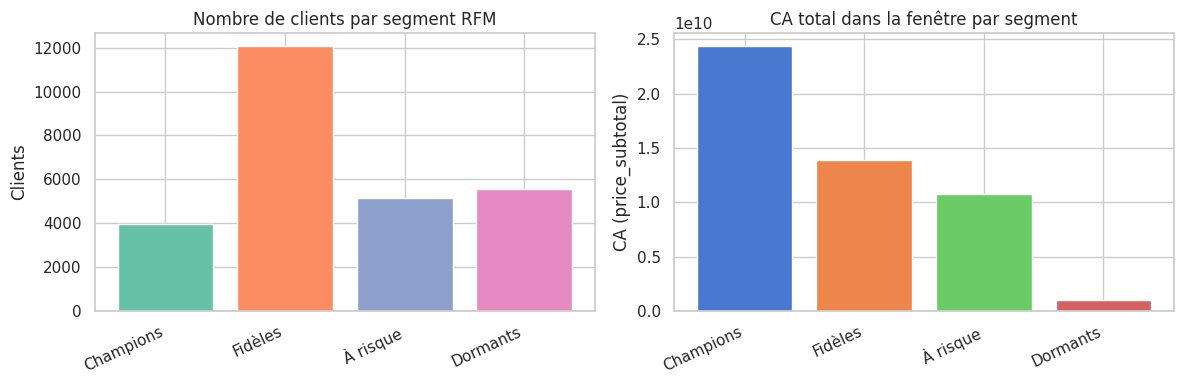

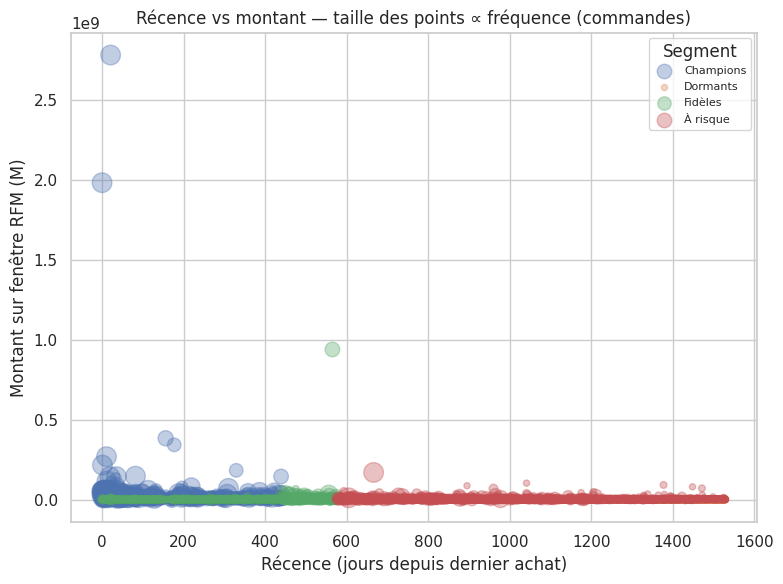

In [12]:
# Graphiques RFM (exécuter la cellule précédente : rfm, df_rfm_win)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

seg_order = ["Champions", "Fidèles", "À risque", "Dormants"]
seg_counts = rfm["segment"].value_counts().reindex(seg_order).fillna(0).astype(int)
axes[0].bar(seg_counts.index, seg_counts.values, color=sns.color_palette("Set2", n_colors=len(seg_counts)))
axes[0].set_title("Nombre de clients par segment RFM")
axes[0].set_ylabel("Clients")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha="right")

seg_ca = df_rfm_win.merge(rfm[["partner_id", "segment"]], on="partner_id", how="inner").groupby(
    "segment", as_index=False
)["price_subtotal"].sum()
seg_ca = seg_ca.set_index("segment").reindex(seg_order).fillna(0)
axes[1].bar(seg_ca.index, seg_ca["price_subtotal"], color=sns.color_palette("muted", n_colors=len(seg_ca)))
axes[1].set_title("CA total dans la fenêtre par segment")
axes[1].set_ylabel("CA (price_subtotal)")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=25, ha="right")

plt.tight_layout()
plt.show()

# Nuage R × M (taille = F) par segment
fig, ax = plt.subplots(figsize=(8, 6))
for seg, sub in rfm.groupby("segment"):
    ax.scatter(
        sub["recency_days"],
        sub["monetary"],
        s=np.clip(sub["frequency"] * 8, 20, 200),
        alpha=0.35,
        label=seg,
    )
ax.set_xlabel("Récence (jours depuis dernier achat)")
ax.set_ylabel("Montant sur fenêtre RFM (M)")
ax.set_title("Récence vs montant — taille des points ∝ fréquence (commandes)")
ax.legend(title="Segment", loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

### Questions métier et réponses RFM

| Question | Comment la RFM y répond |
|----------|---------------------------|
| Qui sont nos **meilleurs clients actifs** ? | Segment **Champions** (et en partie **Fidèles**). |
| Qui **achète encore** mais commence à **s’éloigner** ? | **À risque** — priorité **réactivation**. |
| Qui est **inactif / très froid** ? | **Dormants** — campagnes spécifiques ou pas le même budget. |
| **Combien** de clients par segment ? / **Quel CA** par segment ? | **Effectifs** + **CA agrégé** (voir graphiques de la section RFM). |
| Quelle liste pour une campagne **« VIP fin d’année »** ? | Export des **Champions** (éventuellement + **Fidèles** selon la règle métier). |
 